In [1]:
from misc import *

In [2]:
DEFAULT_FILE_PATH = "/dice/projects/LHCb_PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(DEFAULT_FILE_PATH, DEFAULT_TREE_NAME)



Histogram saved to figures/Jpsi Mass.png
Histogram saved to figures/Jpsi Mass.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass $MeV/c^2$', ylabel='Candidates / 5'>)

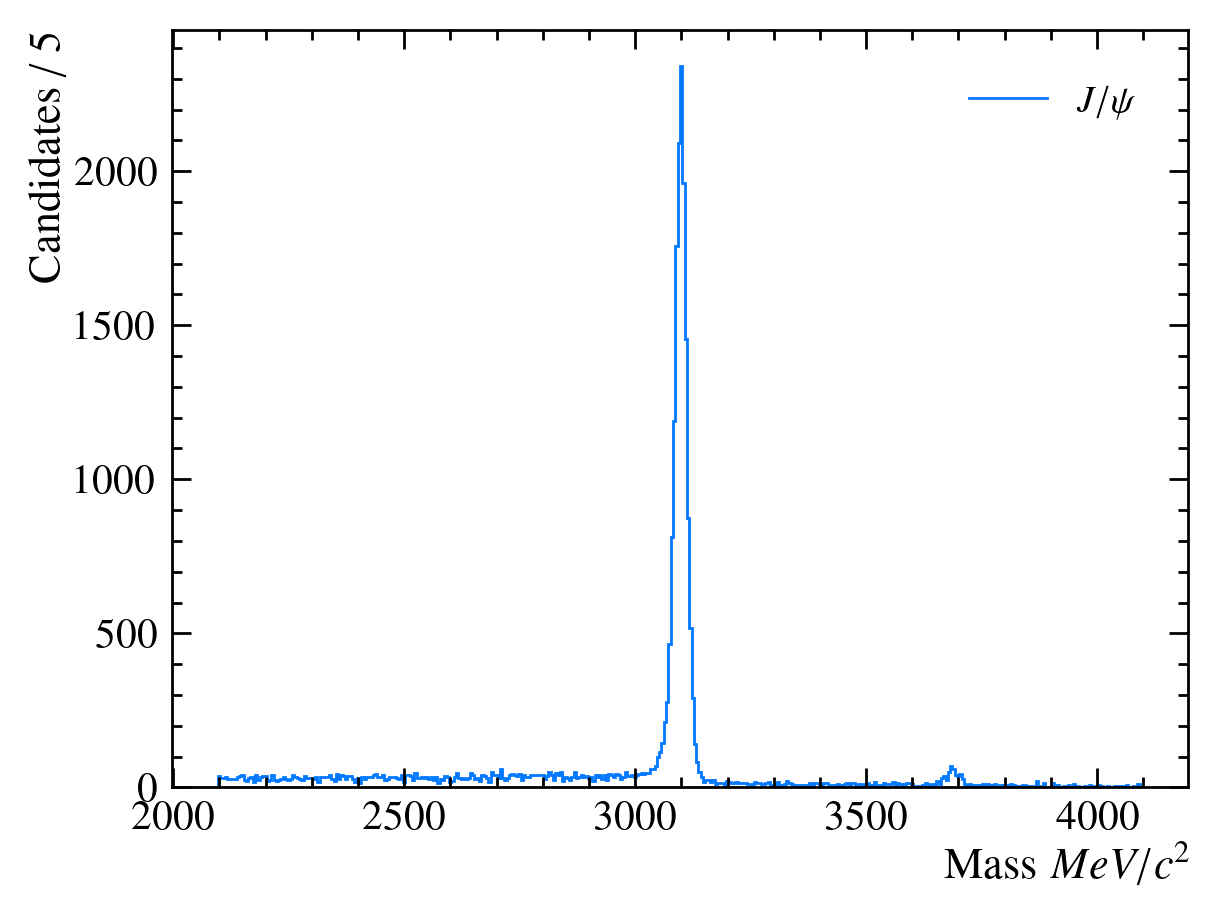

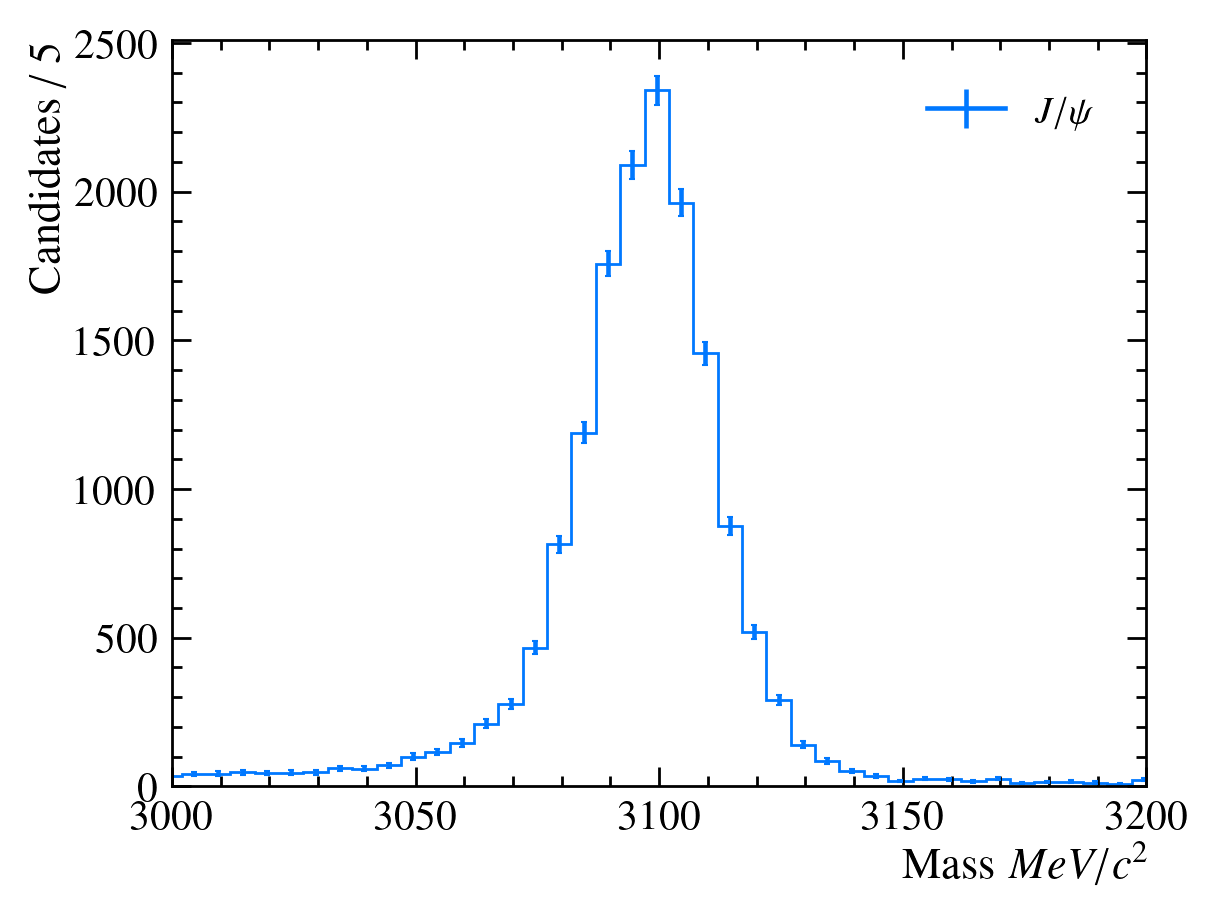

In [3]:
histogram_fig(
    [HistogramPlot(df["J_psi_1S_MM"], r"$J/\psi$", False, 5)],
    "figures/Jpsi Mass.png",
    xlabel="Mass $MeV/c^2$",
)

histogram_fig(
    [HistogramPlot(df["J_psi_1S_MM"], r"$J/\psi$", True, 5)],
    "figures/Jpsi Mass.png",
    xlabel="Mass $MeV/c^2$",
    xlim=[3000, 3200]
)

Histogram saved to figures/Bplus Mass.png


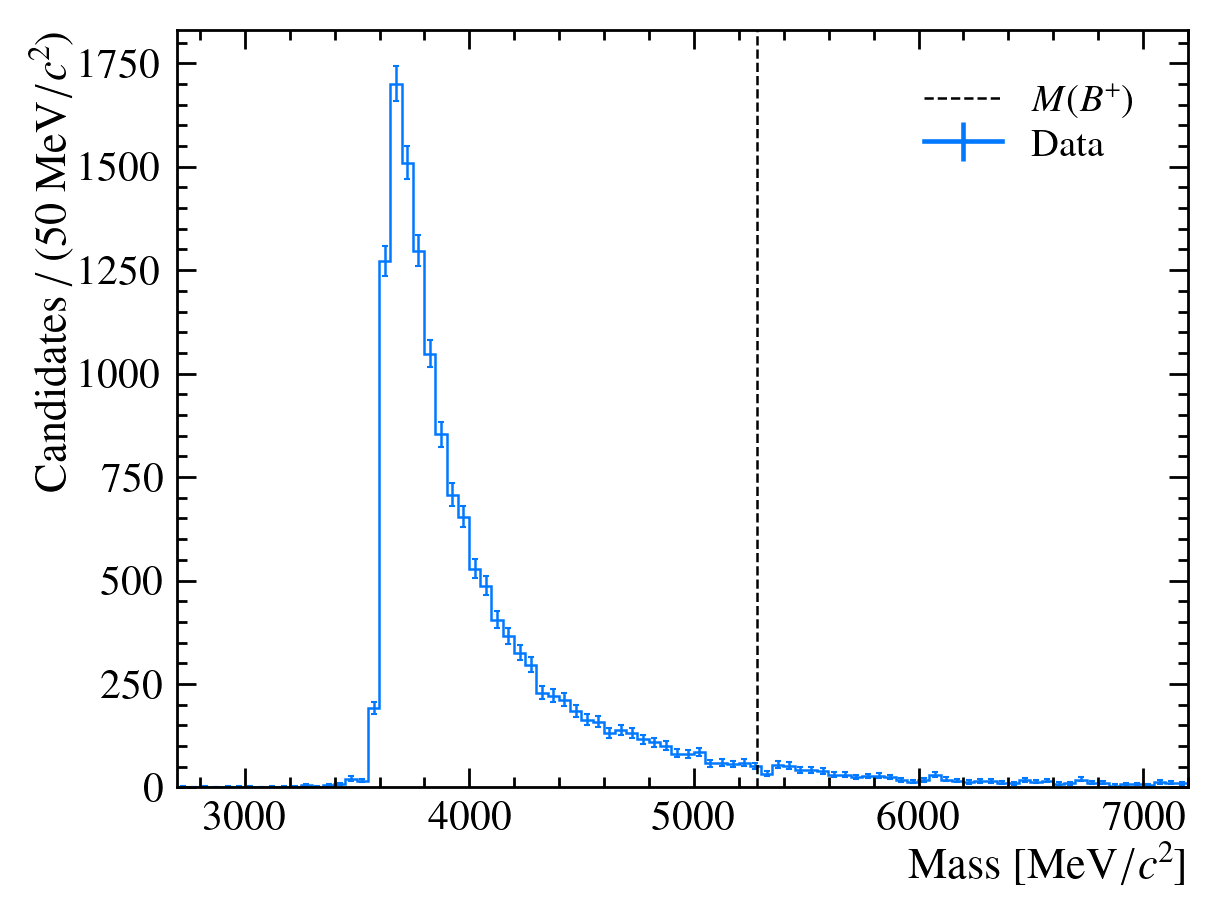

In [ ]:
temp_df = df[df["Kplus_isMuon"] == False]
temp_df = df[(df["J_psi_1S_M"] < constant.JPSI_MASS + 65) & (df["J_psi_1S_M"] > constant.JPSI_MASS - 65)]

fig, ax = histogram_fig(
    [HistogramPlot(temp_df["Bplus_M"], r"Data", True, 50, lw=1.8)],
    "figures/Bplus Mass.png",
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[2700, 7200]
)

ax.axvline(constant.BPLUS_MASS, color="k", ls="--", lw=1.8, label=r"$M(B^+)$")
ax.legend()
# ax.set_yscale("log")

fig.savefig("figures/Report/Bplus_mass.svg")

Histogram saved to figures/week11/Before cuts/Muon momenta.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Momentum $MeV/c$', ylabel='Candidates / 1600.50'>)

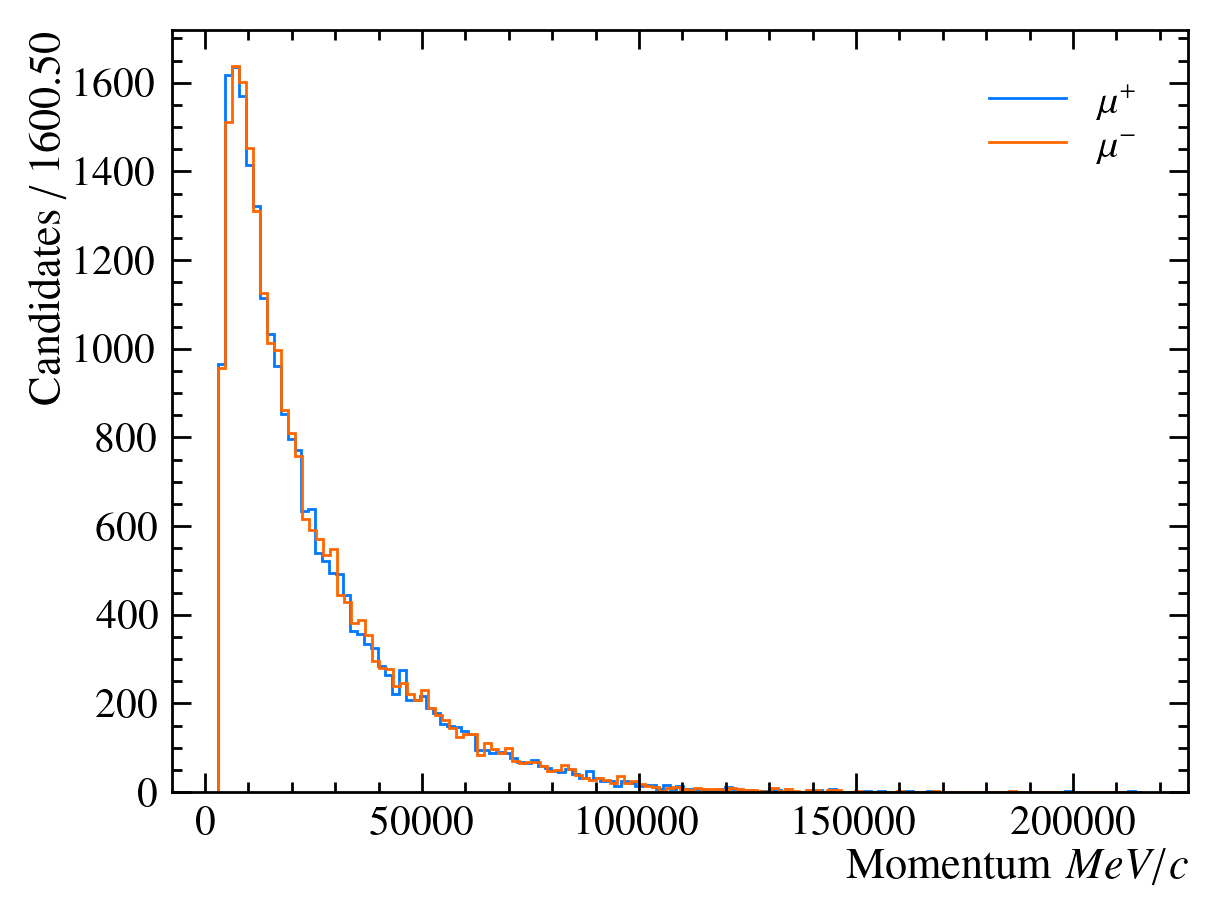

In [ ]:
histogram_fig(
    [
        HistogramPlot(df["muplus_P"], r"$\mu^+$", False),
        HistogramPlot(df["muminus_P"], r"$\mu^-$", False)
    ],
    "figures/week11/Before cuts/Muon momenta.png",

    xlabel=r"Momentum $MeV/c$"
)

Histogram saved to figures/week11/Before cuts/B_end_vertex - B_own_PV.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$|r_{end} - r_{own \\ PV}|$', ylabel='Candidates / 0.1'>)

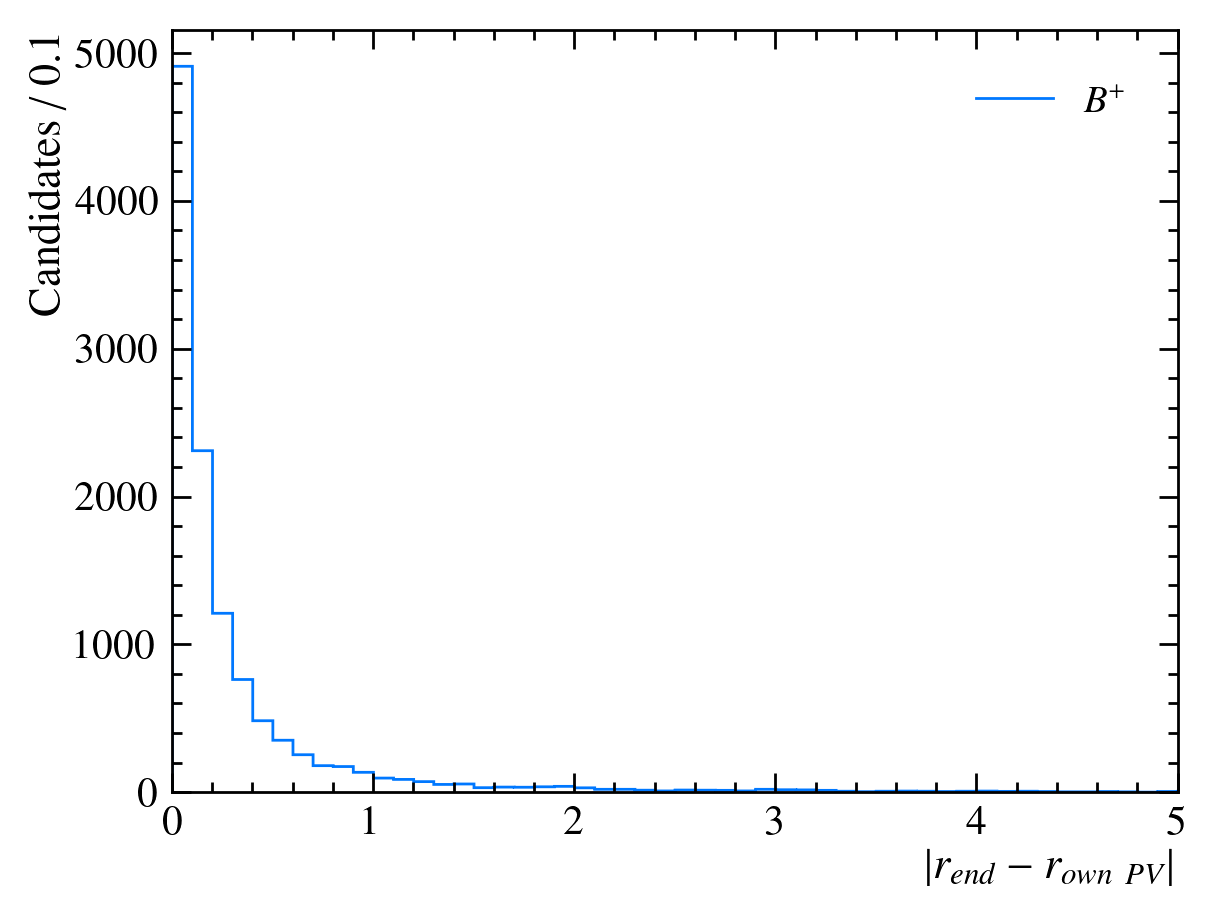

In [ ]:
delta_x = df["Bplus_ENDVERTEX_X"] - df["Bplus_OWNPV_X"]
delta_y = df["Bplus_ENDVERTEX_Y"] - df["Bplus_OWNPV_Y"]
delta_z = df["Bplus_ENDVERTEX_Z"] - df["Bplus_OWNPV_Z"]

B_end_minus_ownpv = np.sqrt(
    delta_x**2 + delta_y**2 + delta_z**2
)

histogram_fig(
    [
        HistogramPlot(B_end_minus_ownpv, r"$B^+$", False, 0.1),
    ],
    "figures/week11/Before cuts/B_end_vertex - B_own_PV.png",
    xlabel=r"$|r_{end} - r_{own \ PV}|$",
    xlim=[0,5]
)



Histogram saved to figures/week11/Before cuts/B_end_chi2.png
Histogram saved to figures/week11/Before cuts/B_end_chi2.png
Histogram saved to figures/week11/Before cuts/B_end_chi2.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$z$', ylabel='Candidates / 0.1'>)

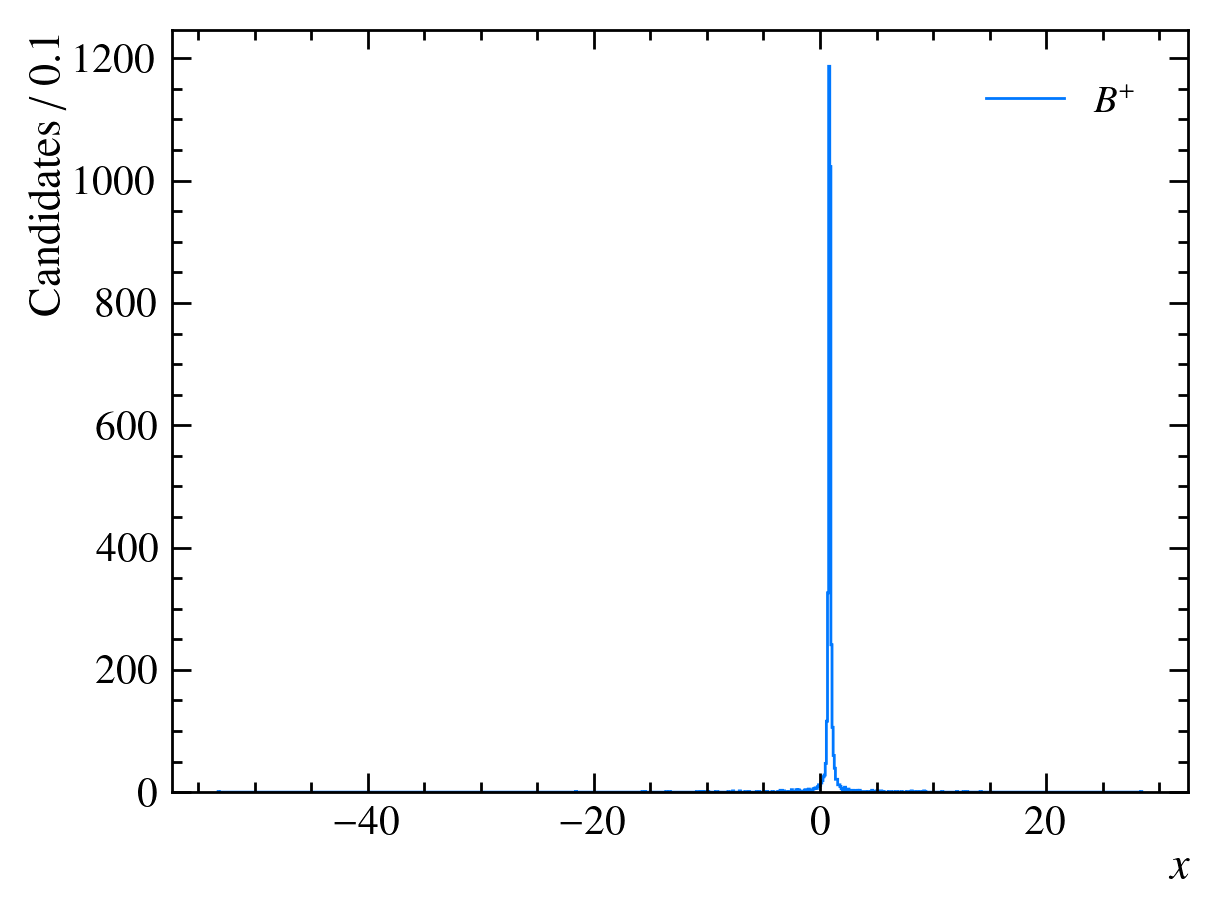

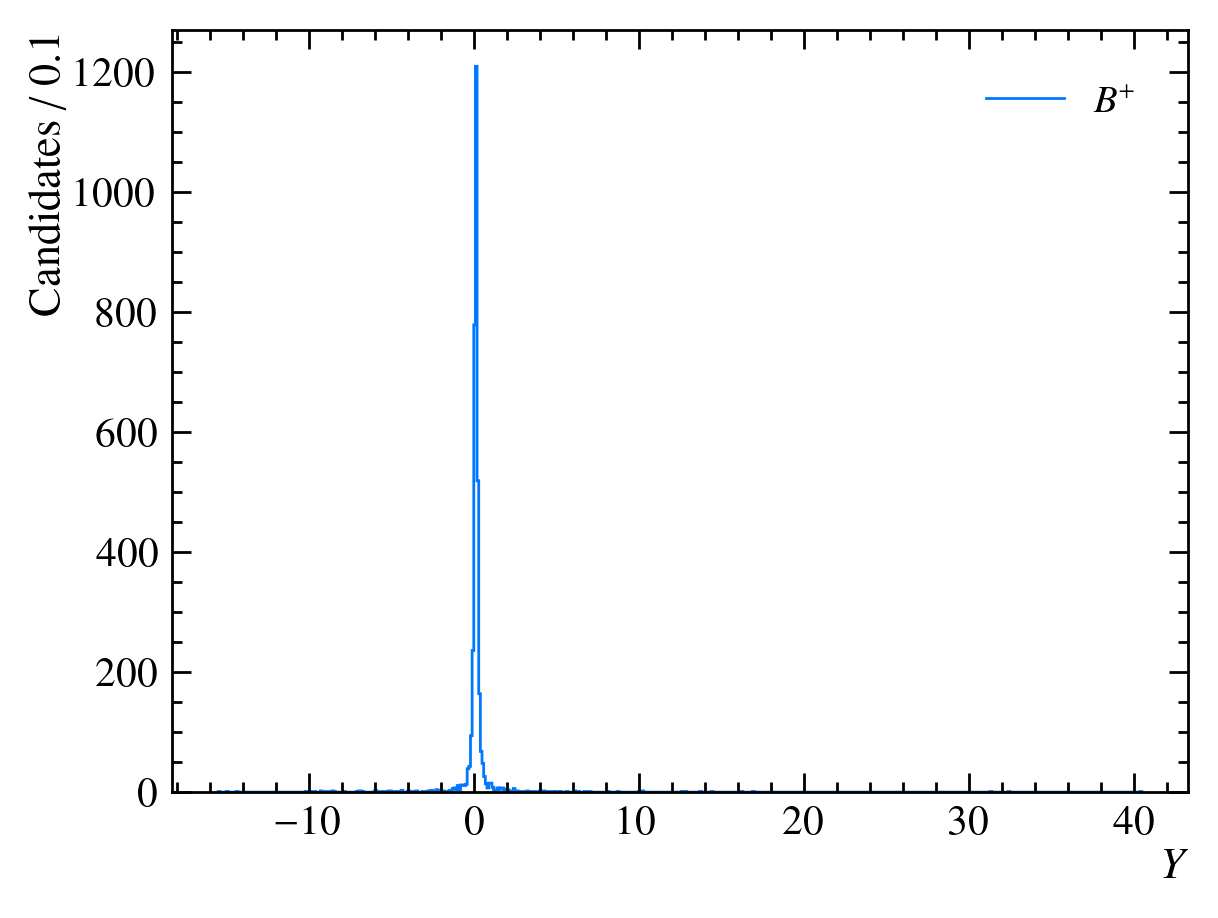

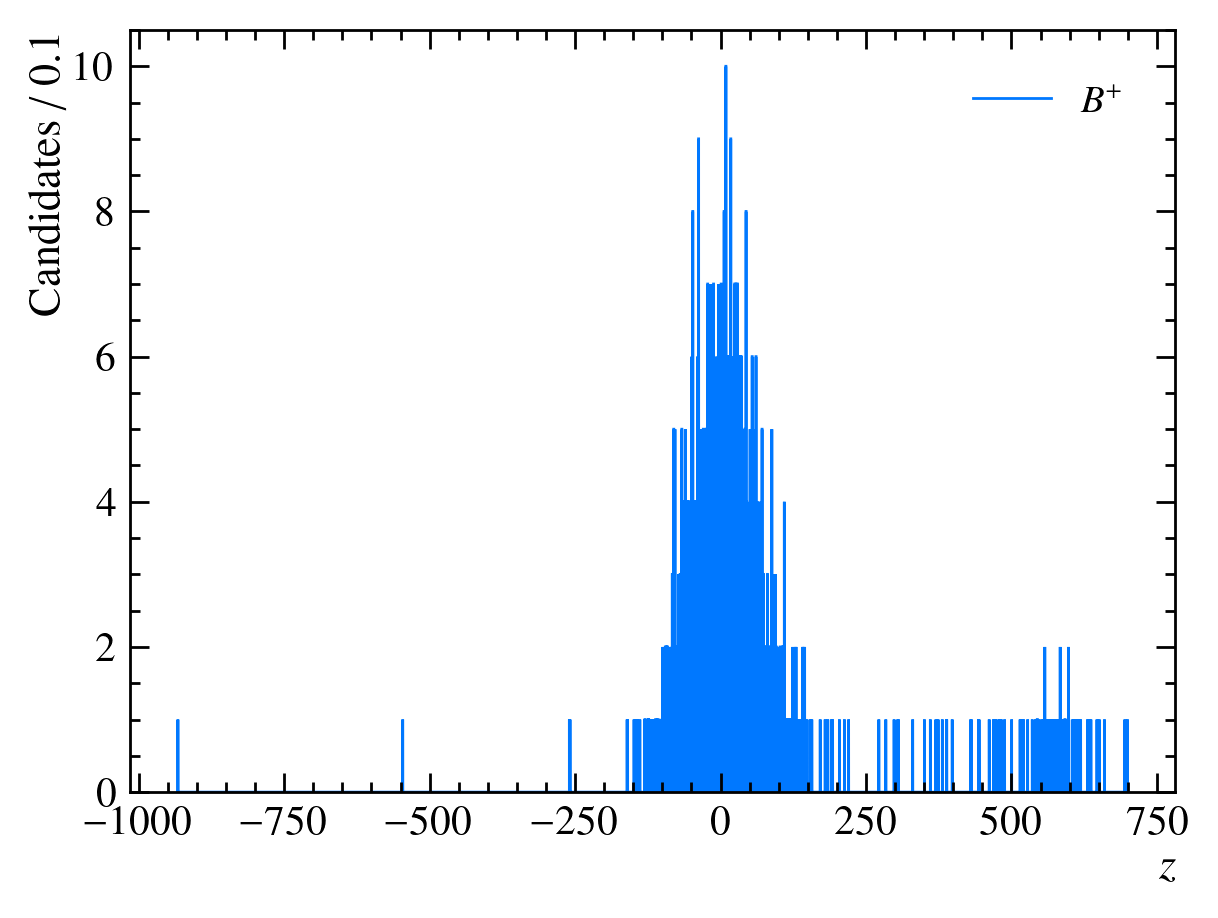

In [ ]:
cut = df[df["Bplus_ENDVERTEX_CHI2"] > 15]

histogram_fig(
    [
        HistogramPlot(cut["Bplus_ENDVERTEX_X"], r"$B^+$", False, 0.1),
    ],
    "figures/week11/Before cuts/B_end_chi2.png",
    xlabel=r"$x$",
)

histogram_fig(
    [
        HistogramPlot(cut["Bplus_ENDVERTEX_Y"], r"$B^+$", False, 0.1),
    ],
    "figures/week11/Before cuts/B_end_chi2.png",
    xlabel=r"$Y$",
)

histogram_fig(
    [
        HistogramPlot(cut["Bplus_ENDVERTEX_Z"], r"$B^+$", False, 0.1),
    ],
    "figures/week11/Before cuts/B_end_chi2.png",
    xlabel=r"$z$",
)

Histogram saved to figures/week11/Before cuts/log_hrc_fom_all.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='HeRSCheL $\\log($FoM)', ylabel='Candidates / 0.102'>)

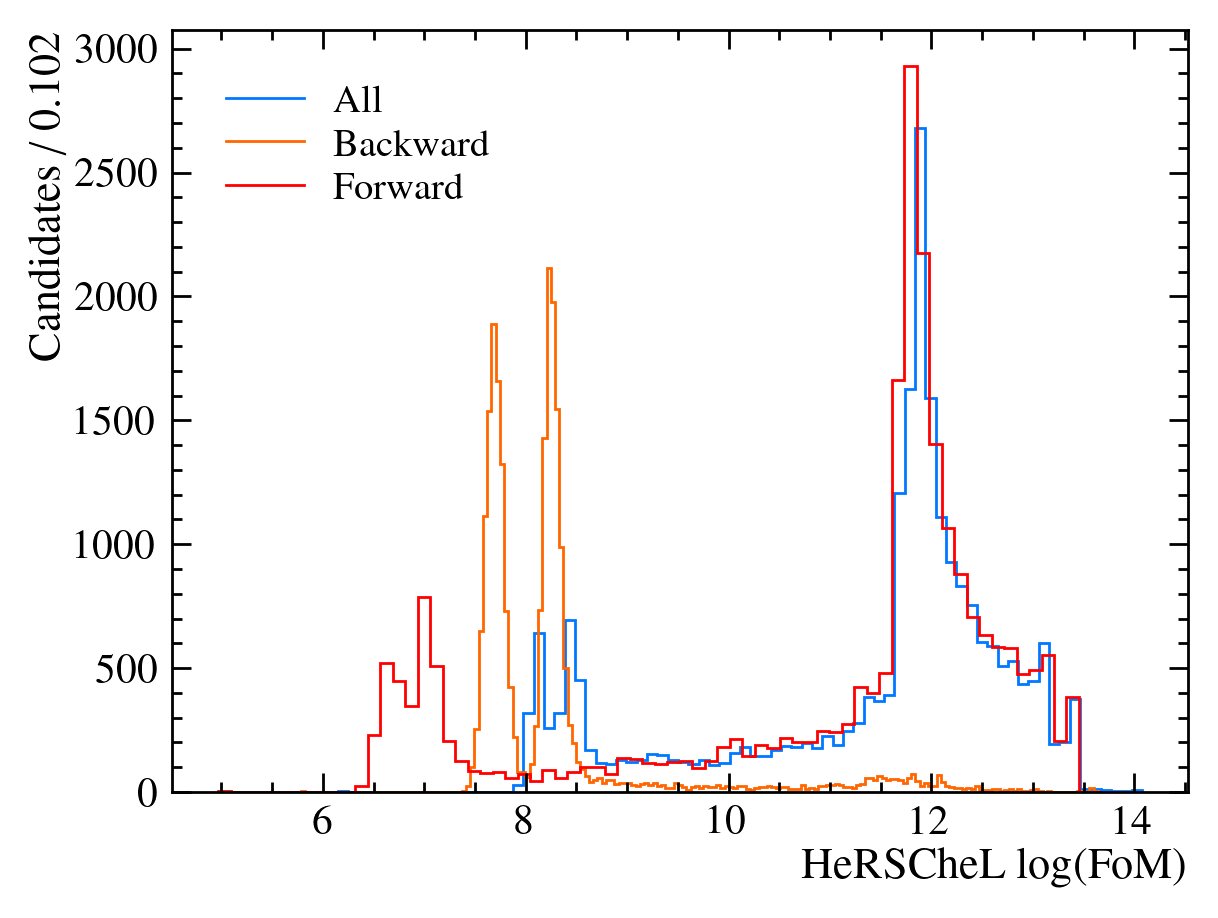

In [ ]:
histogram_fig(
    [
        HistogramPlot(df["log_hrc_fom"], r"All", False),
        HistogramPlot(df["log_hrc_fom_B"], r"Backward", False),
        HistogramPlot(df["log_hrc_fom_F"], r"Forward", False, color="r"),
    ],
    "figures/week11/Before cuts/log_hrc_fom_all.png",
    xlabel=r"HeRSCheL $\log($FoM)",
)

14880
Histogram saved to figures/B_mass.png
Histogram saved to figures/week11/Before cuts/B_mass_cropped.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass $MeV/c^2$', ylabel='Candidates / 5'>)

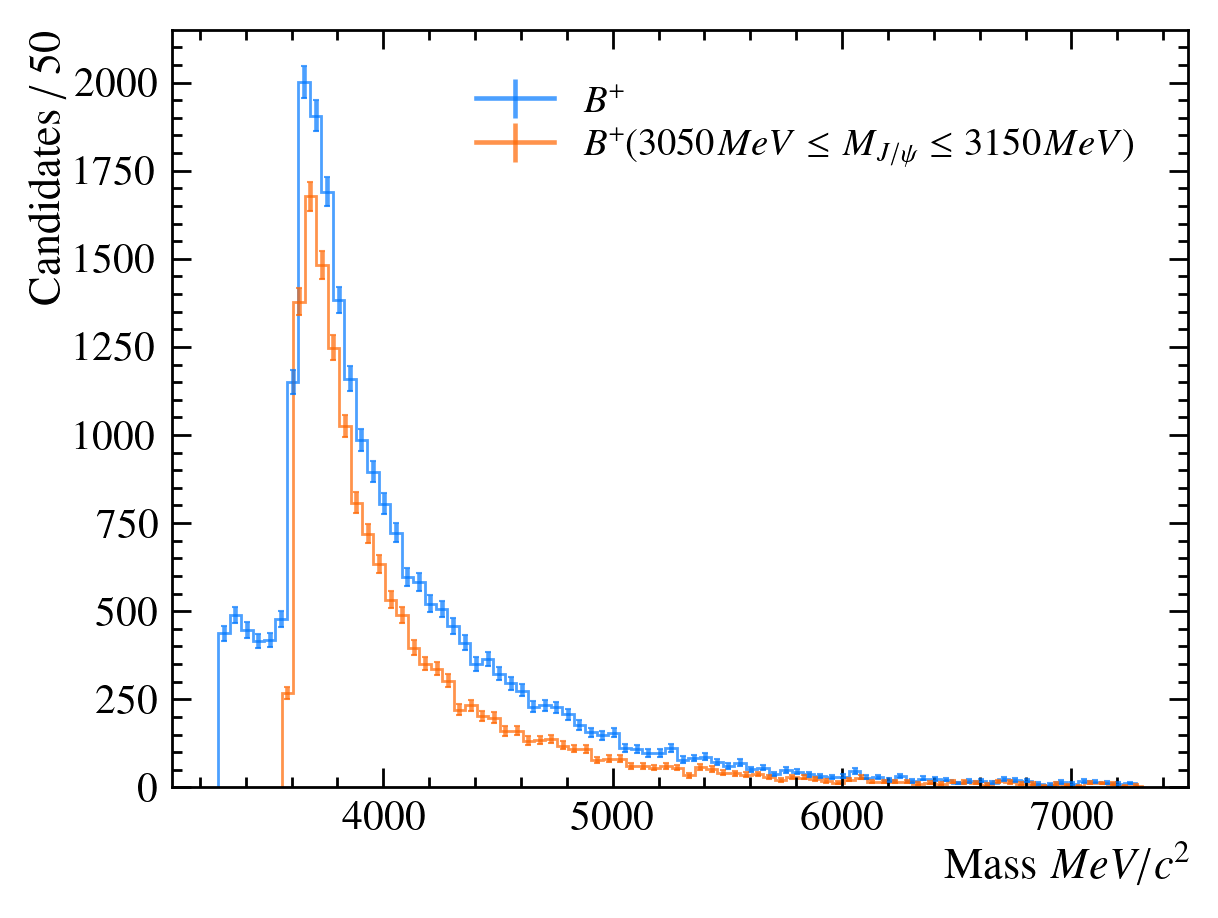

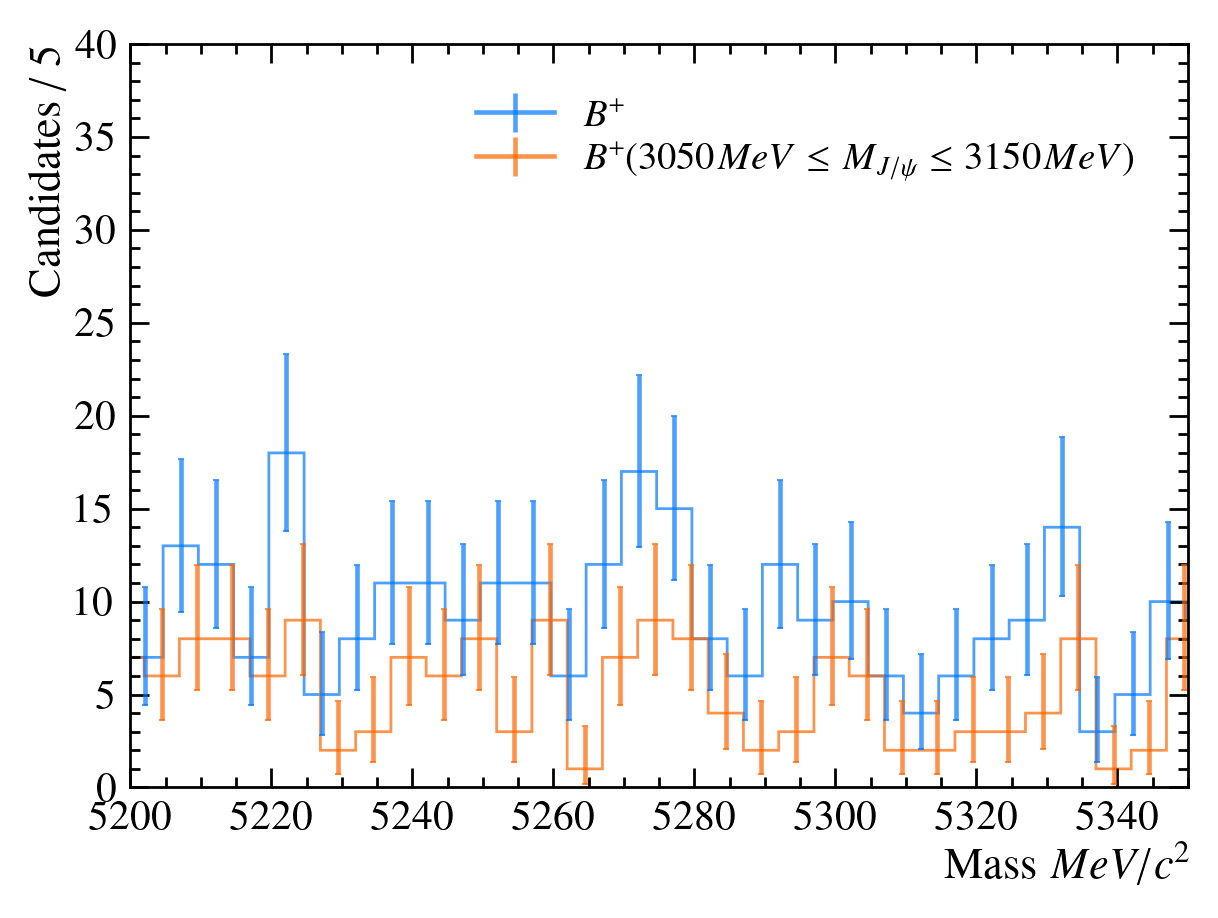

In [ ]:
jpsi_cut_df = df[(3050 <= df["J_psi_1S_MM"]) & (df["J_psi_1S_MM"] <= 3150)]

print(len(jpsi_cut_df))

# histogram_fig(
#     [HistogramPlot(jpsi_cut_df["J_psi_1S_MM"], r"$J/\psi$", False, 5)],
#     "figures/Jpsi Mass.png",
#     xlabel="Mass $MeV/c^2$",
# )

histogram_fig(
    [
        HistogramPlot(df["Bplus_MM"], r"$B^+$", True, 50, alpha=0.7),
        HistogramPlot(
            jpsi_cut_df["Bplus_MM"],
            r"$B^+ (3050MeV \leq M_{J/\psi} \leq 3150MeV)$",
            True,
            50,
            alpha=0.7,
        ),
    ],
    "figures/B_mass.png",
    xlabel=r"Mass $MeV/c^2$",
)
histogram_fig(
    [
        HistogramPlot(df["Bplus_MM"], r"$B^+$", True, 5, alpha=0.7),
        HistogramPlot(
            jpsi_cut_df["Bplus_MM"],
            r"$B^+ (3050MeV \leq M_{J/\psi} \leq 3150MeV)$",
            True,
            5,
            alpha=0.7,
        ),
    ],
    "figures/week11/Before cuts/B_mass_cropped.png",
    xlabel=r"Mass $MeV/c^2$",
    xlim=[5200, 5350],
    ylim=[0,40]
)